# Making Data Count — SPC Chart Builder

Use this notebook to load **your own dataset** and create NHS Making Data Count SPC charts interactively.

**Workflow:**
1. Install / import the package
2. Load your data (CSV, Excel, or build a sample)
3. Preview the data and pick your columns
4. Generate SPC or Run charts with full customisation

## 1. Install and Import the Package

In [1]:
# Install the package in editable mode (run once)
%pip install -i https://test.pypi.org/simple/ abspc

Looking in indexes: https://test.pypi.org/simple/
Note: you may need to restart the kernel to use updated packages.


## 2. Import Dependencies

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abspc import (
    plot_spc_chart,
    plot_run_chart,
    plot_mdc_summary_table,
    calculate_control_limits,
    detect_special_causes,
    detect_run_chart_signals,
    rebase_control_limits,
    determine_point_colours,
    determine_variation_type,
    
    determine_assurance_type,
    validate_data,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print("All imports successful ✓")

All imports successful ✓


## 3. Load Your Data

Update the `file_path` below to point at your CSV or Excel file.  
If you don't have a file handy, skip to **Section 4** where a sample dataset is generated for you.

In [3]:
# ── Option A: Load from a file ──────────────────────────────────────────────
# Uncomment ONE of the lines below and set the path to your file.

# file_path = r"C:\path\to\your\data.csv"
# df = pd.read_csv(file_path, parse_dates=["date"])   # adjust column name

# file_path = r"C:\path\to\your\data.xlsx"
# df = pd.read_excel(file_path, parse_dates=["date"])

# ── Option B: Paste inline data ────────────────────────────────────────────
# df = pd.DataFrame({
#     "date":  pd.date_range("2024-01-01", periods=24, freq="MS"),
#     "value": [12, 14, 11, 15, 13, 10, 9, 8, 7, 6, 5, 11,
#               13, 14, 16, 18, 17, 15, 14, 13, 12, 11, 10, 9],
# })

print("Uncomment one of the options above, or skip to Section 4 for sample data.")

Uncomment one of the options above, or skip to Section 4 for sample data.


## 4. Sample Data (skip if you loaded your own above)

Generates 24 months of synthetic data with some special-cause variation built in, so the charts have something interesting to show.

In [4]:
np.random.seed(42)

dates = pd.date_range("2022-01-01", periods=48, freq="MS")
base = np.random.normal(loc=50, scale=4, size=48)

# Phase 1 (months 1-20): stable common-cause variation around 50
# Inject an astronomical outlier at month 10
base[9] = 72

# Phase 2 (months 21-48): sustained step-change upward (~+15)
# This shift of ≥ 7 consecutive points above the original mean
# should trigger a rebase / rephase.
base[20:] += 15

# Add a small downward trend at the end (months 40-48) for variety
base[39:] -= np.linspace(0, 6, 9)

df = pd.DataFrame({"date": dates, "value": np.round(base, 1)})
print(f"{len(df)} data points  |  {df['date'].min():%b %Y} → {df['date'].max():%b %Y}")
df.head(10)

48 data points  |  Jan 2022 → Dec 2025


,date,value
0,2022-01-01,52.0
1,2022-02-01,49.4
2,2022-03-01,52.6
3,2022-04-01,56.1
4,2022-05-01,49.1
5,2022-06-01,49.1
6,2022-07-01,56.3
7,2022-08-01,53.1
8,2022-09-01,48.1
9,2022-10-01,72.0


## 5. Preview and Pick Your Columns

Check the column names and set the variables below to match your dataset.  
The defaults work with the sample data generated above.

In [5]:
# ── Configuration — edit these to match YOUR data ──────────────────────────
VALUE_COL = "value"          # column with the metric values
DATE_COL  = "date"           # column with dates (set to None if no dates)
SUBGROUP_COL = None          # needed for p / u charts (e.g. "subgroup_size")

# Quick look at the data
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.describe()

Shape: (48, 2)
Columns: ['date', 'value']


,date,value
count,48,48.000000
mean,2023-12-16 11:00:00,57.779167
min,2022-01-01 00:00:00,42.300000
25%,2022-12-24 06:00:00,50.600000
50%,2023-12-16 12:00:00,59.500000
75%,2024-12-08 18:00:00,64.125000
max,2025-12-01 00:00:00,72.400000
std,NaN,8.148749


## 6. XmR Chart (Individuals & Moving Range)

The most common SPC chart type — one measurement per time period.

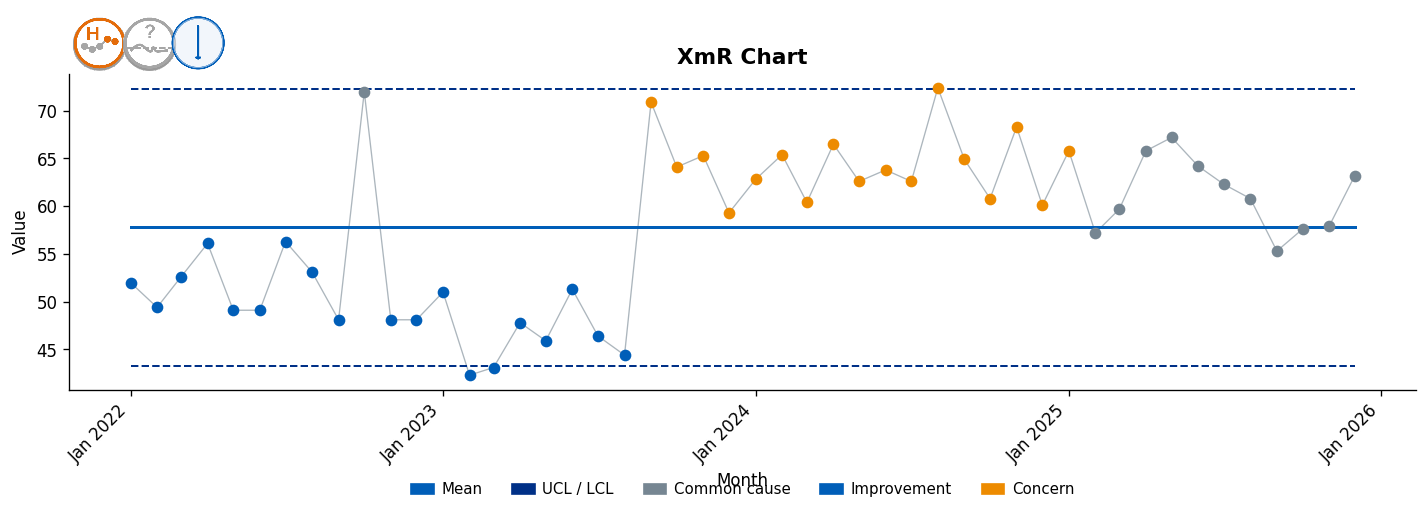

In [23]:
fig, ax = plot_spc_chart(
    df,
    chart_type="XmR",
    value_col=VALUE_COL,
    x_col=DATE_COL,
    title="XmR Chart",
    xlabel="Month",
    ylabel=VALUE_COL.title(),
    improvement_direction="low",
    date_format="%b %Y",
    show_icons=True,
    target=50,
    show_target=False
)
plt.show()

## 7. XmR Chart with Target Line and Shading

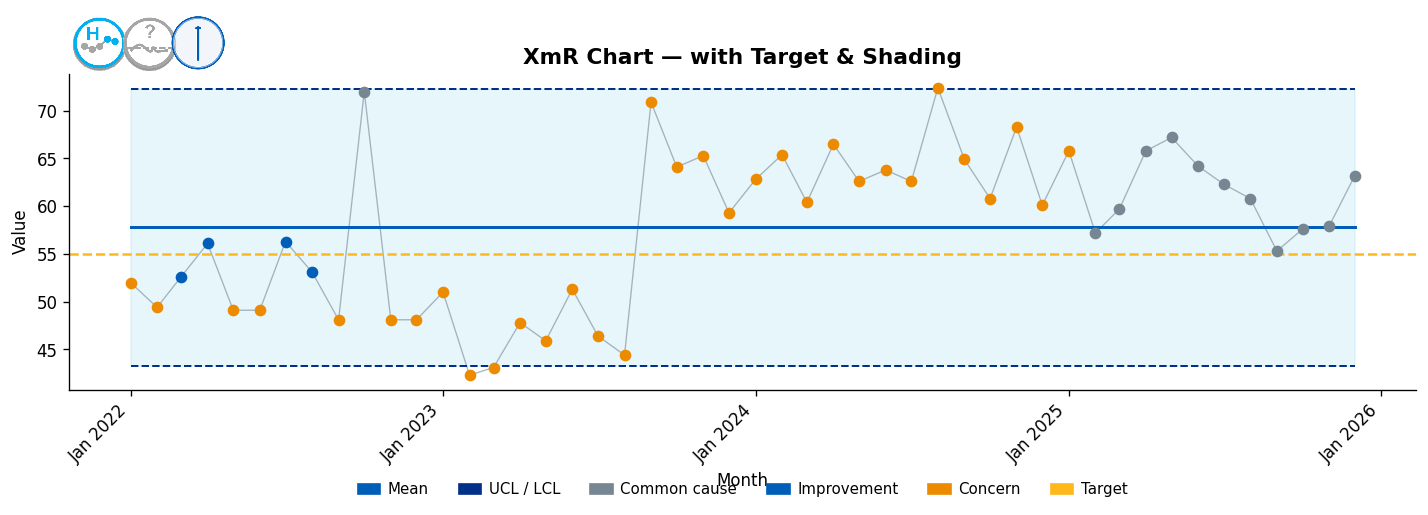

In [7]:
fig, ax = plot_spc_chart(
    df,
    chart_type="XmR",
    value_col=VALUE_COL,
    x_col=DATE_COL,
    title="XmR Chart — with Target & Shading",
    xlabel="Month",
    ylabel=VALUE_COL.title(),
    improvement_direction="high",
    target=55,
    show_target=True,
    shade_band=True,
    date_format="%b %Y",
    show_icons=True,
)
plt.show()

## 8. XmR Chart with Auto-Rebase

Automatically detects sustained shifts and recalculates control limits for each phase.

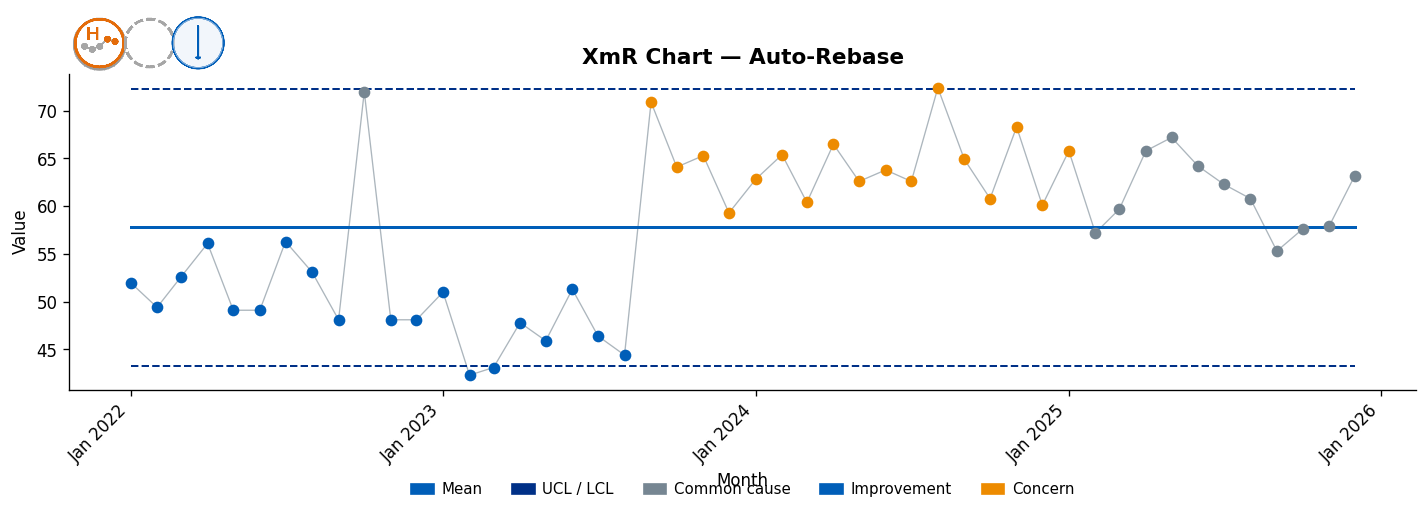

In [8]:
fig, ax = plot_spc_chart(
    df,
    chart_type="XmR",
    value_col=VALUE_COL,
    x_col=DATE_COL,
    title="XmR Chart — Auto-Rebase",
    xlabel="Month",
    ylabel=VALUE_COL.title(),
    improvement_direction="low",
    ##auto_rebase=True,
    date_format="%b %Y",
    show_icons=True,
)
plt.show()

## 8b. Rephased Control Limits (inspect the data)

Use `rebase_control_limits` directly to see where the phases are detected and how the mean / UCL / LCL change at each phase boundary.

In [9]:
# Calculate rephased limits
rephased = rebase_control_limits(
    df,
    chart_type="XmR",
    improvement_direction="high",
    value_col=VALUE_COL,
)

# How many phases were detected?
n_phases = rephased["rebase_phase"].nunique()
print(f"Phases detected: {n_phases}")

# Show key columns including the phase assignment
rephased[[VALUE_COL, "mean", "ucl", "lcl", "rebase_phase"]]

Phases detected: 2


,value,mean,ucl,lcl,rebase_phase
0,52.0,57.779167,72.265360,43.292974,0
1,49.4,57.779167,72.265360,43.292974,0
2,52.6,57.779167,72.265360,43.292974,0
3,56.1,57.779167,72.265360,43.292974,0
4,49.1,57.779167,72.265360,43.292974,0
5,49.1,57.779167,72.265360,43.292974,0
6,56.3,57.779167,72.265360,43.292974,0
7,53.1,57.779167,72.265360,43.292974,0
8,48.1,57.779167,72.265360,43.292974,0
9,72.0,57.779167,72.265360,43.292974,0


### Compare: Original vs Rephased Limits

Side-by-side so you can see the impact of rephasing on the mean and control limits.

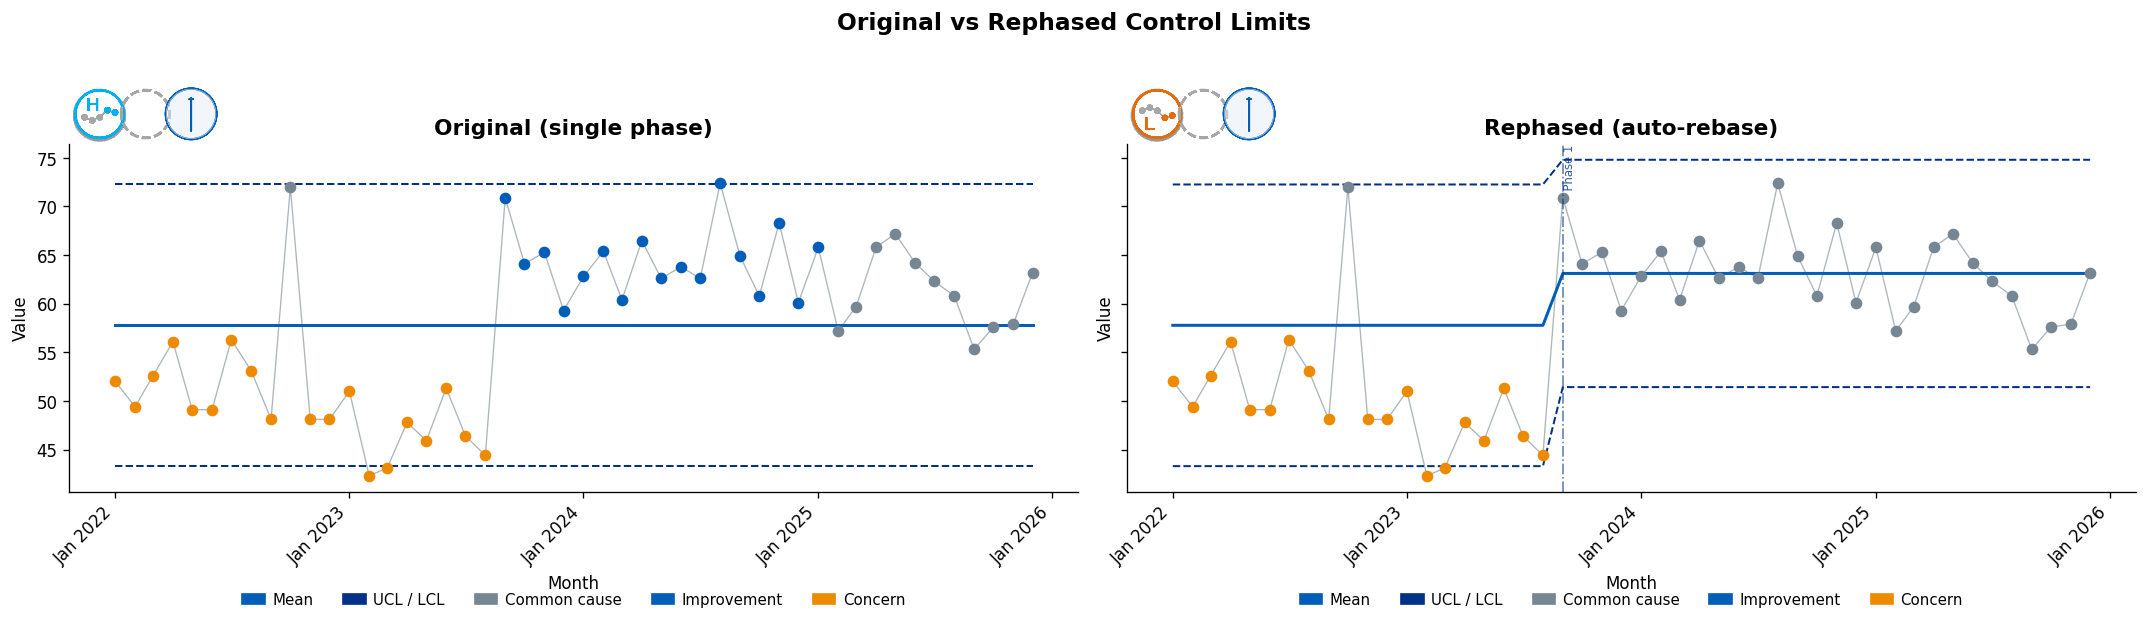

In [10]:
# Original (no rebase) vs Rephased — side by side
original = calculate_control_limits(df, chart_type="XmR", value_col=VALUE_COL)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# Left: original
plot_spc_chart(
    df, chart_type="XmR", value_col=VALUE_COL, x_col=DATE_COL,
    title="Original (single phase)", xlabel="Month", ylabel=VALUE_COL.title(),
    date_format="%b %Y", ax=ax1, show_icons=True,
)

# Right: rephased
plot_spc_chart(
    df, chart_type="XmR", value_col=VALUE_COL, x_col=DATE_COL,
    title="Rephased (auto-rebase)", xlabel="Month", ylabel=VALUE_COL.title(),
    date_format="%b %Y", auto_rebase=True, ax=ax2, show_icons=True,
)

fig.suptitle("Original vs Rephased Control Limits", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### Rephased — Per-Phase Summary

Summary statistics for each detected phase.

In [11]:
# Per-phase summary: points, mean, UCL, LCL
phase_summary = (
    rephased.groupby("rebase_phase")
    .agg(
        points=(VALUE_COL, "count"),
        mean_value=(VALUE_COL, "mean"),
        centre_line=("mean", "first"),
        ucl=("ucl", "first"),
        lcl=("lcl", "first"),
    )
    .round(2)
)
phase_summary

,points,mean_value,centre_line,ucl,lcl
rebase_phase,,,,,
0,20,50.31,57.78,72.27,43.29
1,28,63.11,63.11,74.81,51.42


## 9. Run Chart

A simpler chart with a median centre line and no control limits — useful for early-stage data.

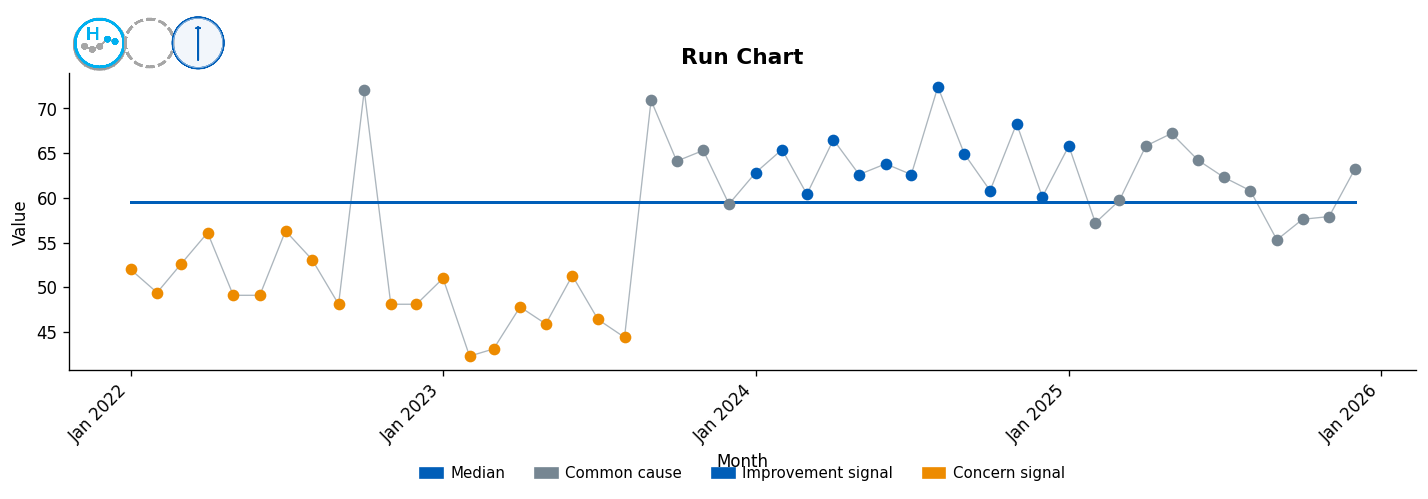

In [12]:
fig, ax = plot_run_chart(
    df,
    value_col=VALUE_COL,
    x_col=DATE_COL,
    title="Run Chart",
    xlabel="Month",
    ylabel=VALUE_COL.title(),
    improvement_direction="high",
    date_format="%b %Y",
    show_icons=True,
)
plt.show()

## 10. Inspect Control Limits and Special-Cause Flags

Use the lower-level API to see the calculated limits and which points are flagged.

In [13]:
# Calculate control limits
result = calculate_control_limits(df, chart_type="XmR", value_col=VALUE_COL)

# Detect special-cause variation
result = detect_special_causes(result, value_col=VALUE_COL)

# Show the flagged columns
flag_cols = [VALUE_COL, "mean", "ucl", "lcl", "rule1", "rule2", "rule3"]
# Include rule4 if present
if "rule4" in result.columns:
    flag_cols.append("rule4")
if "special_cause" in result.columns:
    flag_cols.append("special_cause")

result[flag_cols]

,value,mean,ucl,lcl,rule1,rule2,rule3,rule4,special_cause
0,52.0,57.779167,72.26536,43.292974,False,True,False,False,True
1,49.4,57.779167,72.26536,43.292974,False,True,False,False,True
2,52.6,57.779167,72.26536,43.292974,False,True,False,False,True
3,56.1,57.779167,72.26536,43.292974,False,True,False,False,True
4,49.1,57.779167,72.26536,43.292974,False,True,False,False,True
5,49.1,57.779167,72.26536,43.292974,False,True,False,False,True
6,56.3,57.779167,72.26536,43.292974,False,True,False,False,True
7,53.1,57.779167,72.26536,43.292974,False,True,False,False,True
8,48.1,57.779167,72.26536,43.292974,False,True,False,False,True
9,72.0,57.779167,72.26536,43.292974,False,False,False,False,False


## 11. Point Colours (Improvement / Concern / Common Cause)

In [14]:
colours = determine_point_colours(
    result,
    value_col=VALUE_COL,
    improvement_direction="high",
)

result["colour"] = colours
print("Colour counts:")
print(pd.Series(colours).value_counts())
result[[VALUE_COL, "colour"]].head(10)

Colour counts:
#ED8B00    19
#005EB8    17
#768692    12
Name: count, dtype: int64


,value,colour
0,52.0,#ED8B00
1,49.4,#ED8B00
2,52.6,#ED8B00
3,56.1,#ED8B00
4,49.1,#ED8B00
5,49.1,#ED8B00
6,56.3,#ED8B00
7,53.1,#ED8B00
8,48.1,#ED8B00
9,72.0,#768692


## 12. p-Chart Example (Proportions)

Create sample proportion data with a denominator column, or adapt to your own dataset.

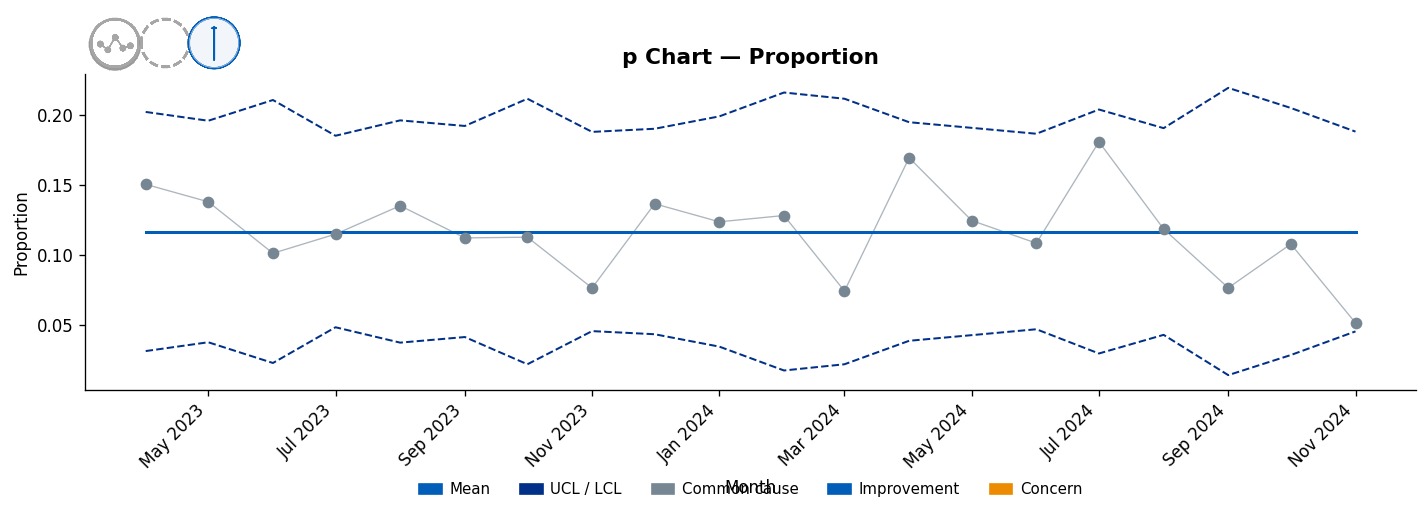

In [15]:
# Sample p-chart data
np.random.seed(7)
n_samples = 20
denominators = np.random.randint(80, 200, size=n_samples)
proportions = np.clip(np.random.normal(0.12, 0.03, size=n_samples), 0, 1)

df_p = pd.DataFrame({
    "date": pd.date_range("2023-04-01", periods=n_samples, freq="MS"),
    "value": np.round(proportions, 4),
    "subgroup_size": denominators,
})

fig, ax = plot_spc_chart(
    df_p,
    chart_type="p",
    value_col="value",
    subgroup_col="subgroup_size",
    x_col="date",
    title="p Chart — Proportion",
    xlabel="Month",
    ylabel="Proportion",
    date_format="%b %Y",
    show_icons=True,
)
plt.show()

## 13. c-Chart Example (Counts)

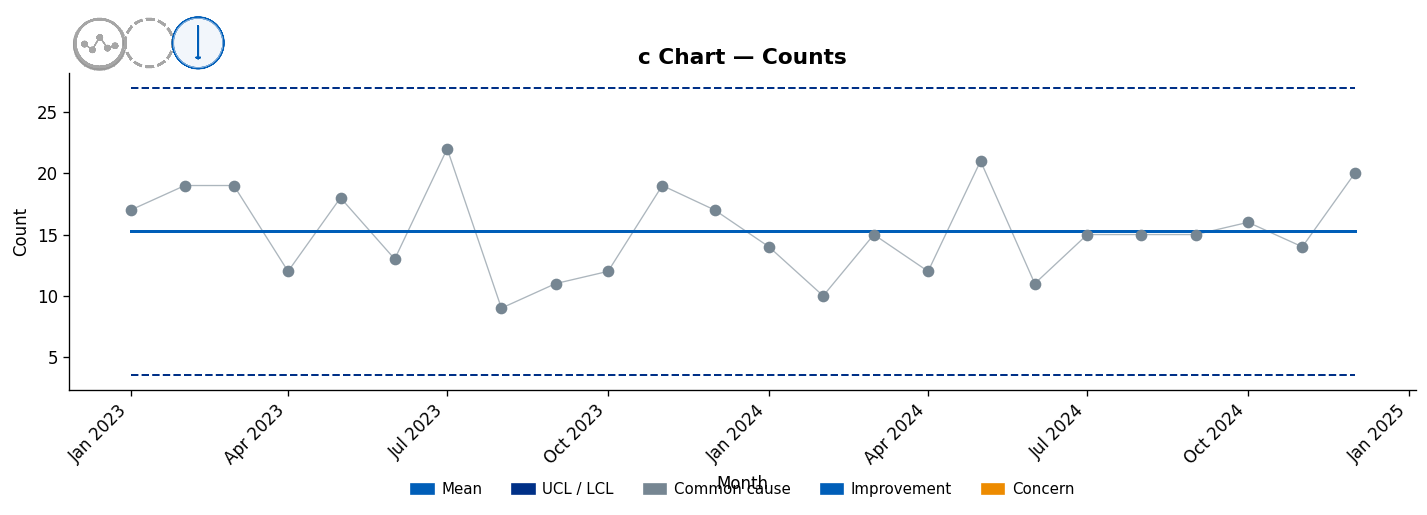

In [16]:
# Sample c-chart data (counts in a fixed population)
np.random.seed(99)
df_c = pd.DataFrame({
    "date": pd.date_range("2023-01-01", periods=24, freq="MS"),
    "value": np.random.poisson(lam=15, size=24),
})

fig, ax = plot_spc_chart(
    df_c,
    chart_type="c",
    value_col="value",
    x_col="date",
    title="c Chart — Counts",
    xlabel="Month",
    ylabel="Count",
    improvement_direction="low",
    date_format="%b %Y",
    show_icons=True,
)
plt.show()

## 14. Change Points and Annotations

Mark known process changes on the chart with vertical lines and labels.

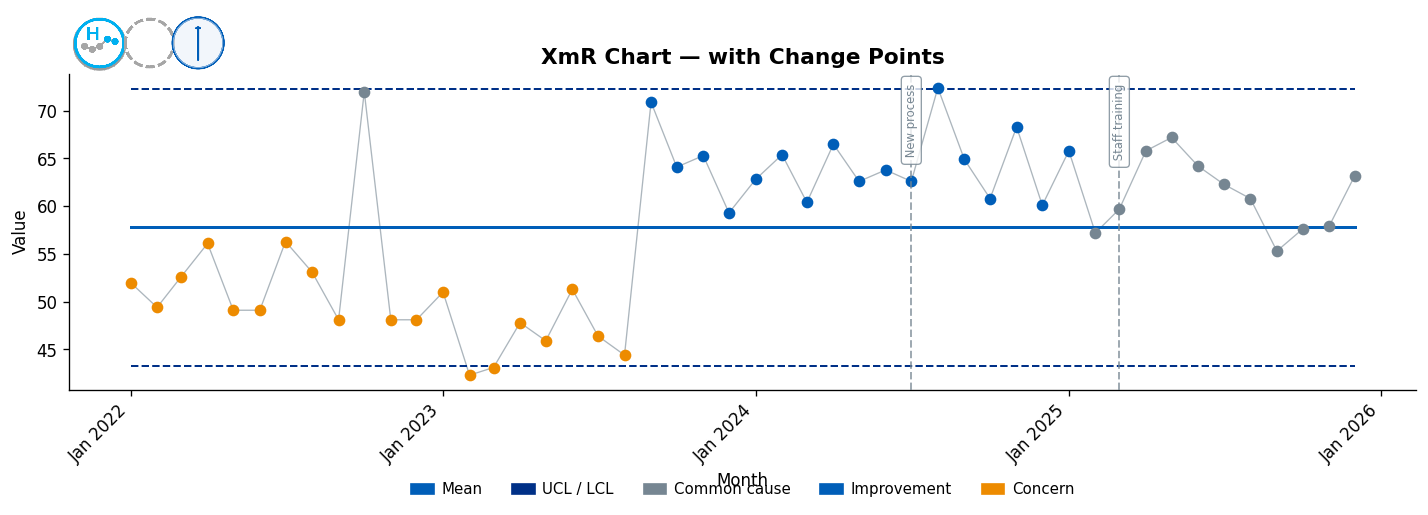

In [17]:
fig, ax = plot_spc_chart(
    df,
    chart_type="XmR",
    value_col=VALUE_COL,
    x_col=DATE_COL,
    title="XmR Chart — with Change Points",
    xlabel="Month",
    ylabel=VALUE_COL.title(),
    improvement_direction="high",
    date_format="%b %Y",
    show_icons=True,
    change_points=[
        {"x": pd.Timestamp("2024-07-01"), "label": "New process"},
        {"x": pd.Timestamp("2025-03-01"), "label": "Staff training"},
    ],
)
plt.show()

## 15. Side-by-Side Comparison

Plot two chart types next to each other for the same data — handy for presentations.

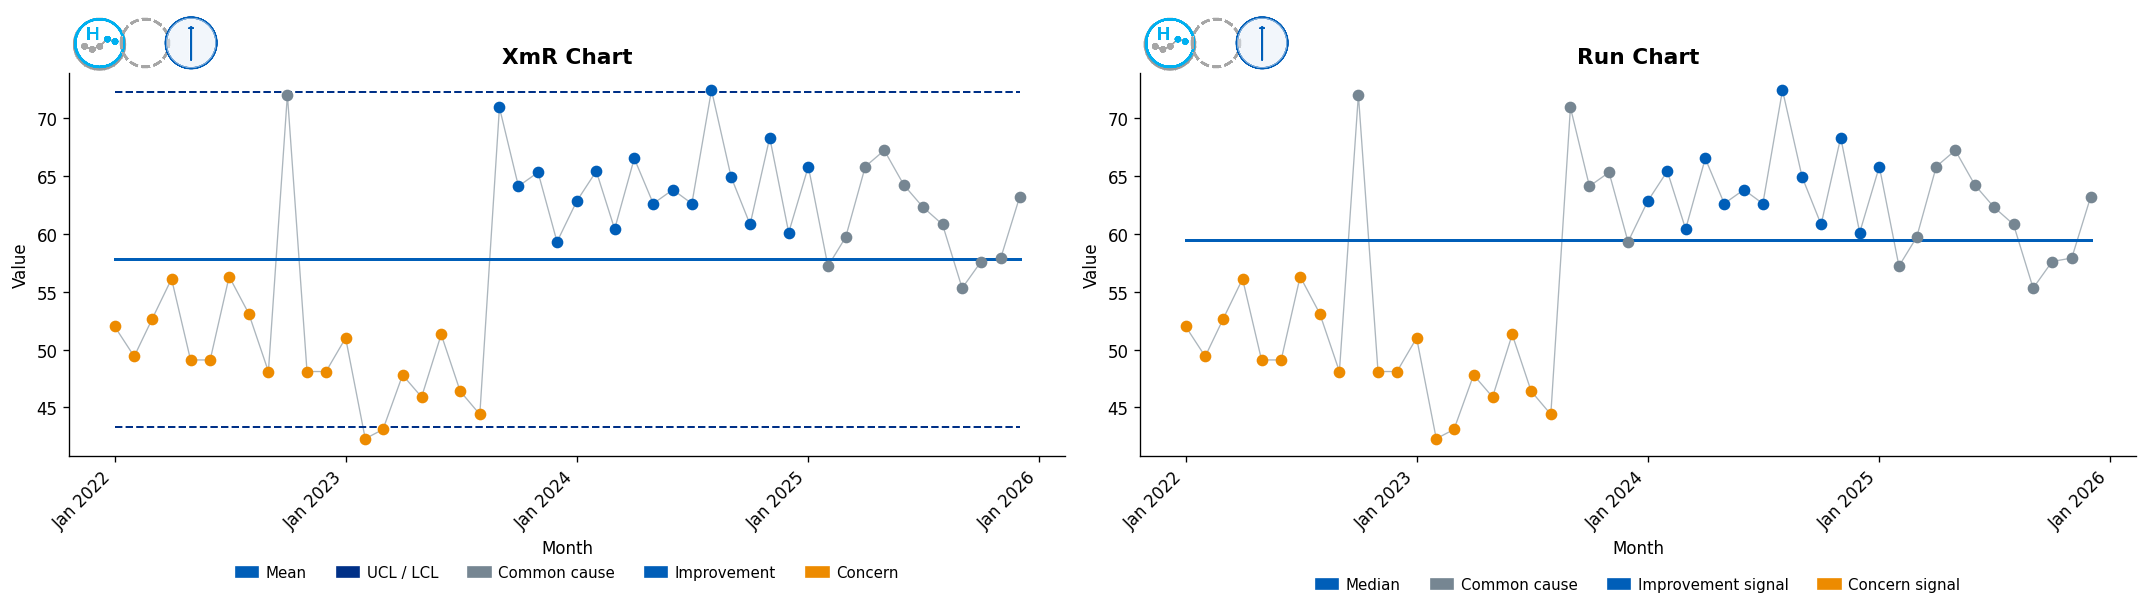

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

plot_spc_chart(
    df, chart_type="XmR", value_col=VALUE_COL, x_col=DATE_COL,
    title="XmR Chart", xlabel="Month", ylabel=VALUE_COL.title(),
    date_format="%b %Y", ax=ax1, show_icons=True,
)

plot_run_chart(
    df, value_col=VALUE_COL, x_col=DATE_COL,
    title="Run Chart", xlabel="Month", ylabel=VALUE_COL.title(),
    date_format="%b %Y", ax=ax2, show_icons=True,
)

fig.tight_layout()
plt.show()

## 16. Edge Cases and Validation

Quick checks that the package raises clear errors for invalid inputs.

In [19]:
# Test 1: Empty DataFrame
try:
    validate_data(pd.DataFrame(), "xmr")
except ValueError as e:
    print(f"Empty DF      → {e}")

# Test 2: Missing value column
try:
    validate_data(pd.DataFrame({"x": [1, 2]}), "xmr", value_col="value")
except ValueError as e:
    print(f"Missing col   → {e}")

# Test 3: Non-numeric values
try:
    validate_data(pd.DataFrame({"value": ["a", "b", "c"]}), "xmr")
except ValueError as e:
    print(f"Non-numeric   → {e}")

# Test 4: Not a DataFrame
try:
    validate_data([1, 2, 3], "xmr")
except TypeError as e:
    print(f"Wrong type    → {e}")

# Test 5: p-chart without subgroup column
try:
    validate_data(pd.DataFrame({"value": [0.1, 0.2]}), "p")
except ValueError as e:
    print(f"No subgroup   → {e}")

print("\nAll validation checks passed ✓")

Empty DF      → data DataFrame is empty
Missing col   → Column 'value' not found in data. Available columns: ['x']
Non-numeric   → Column 'value' must be numeric, got dtype 'object'
Wrong type    → data must be a pandas DataFrame, got list
No subgroup   → Chart type 'p' requires a subgroup size column. Expected column 'subgroup_size' in data. Available columns: ['value']

All validation checks passed ✓


## 17. Export a Chart to PNG

Save the current chart to a file — ready for reports or presentations.

Chart saved to: spc_chart_output.png


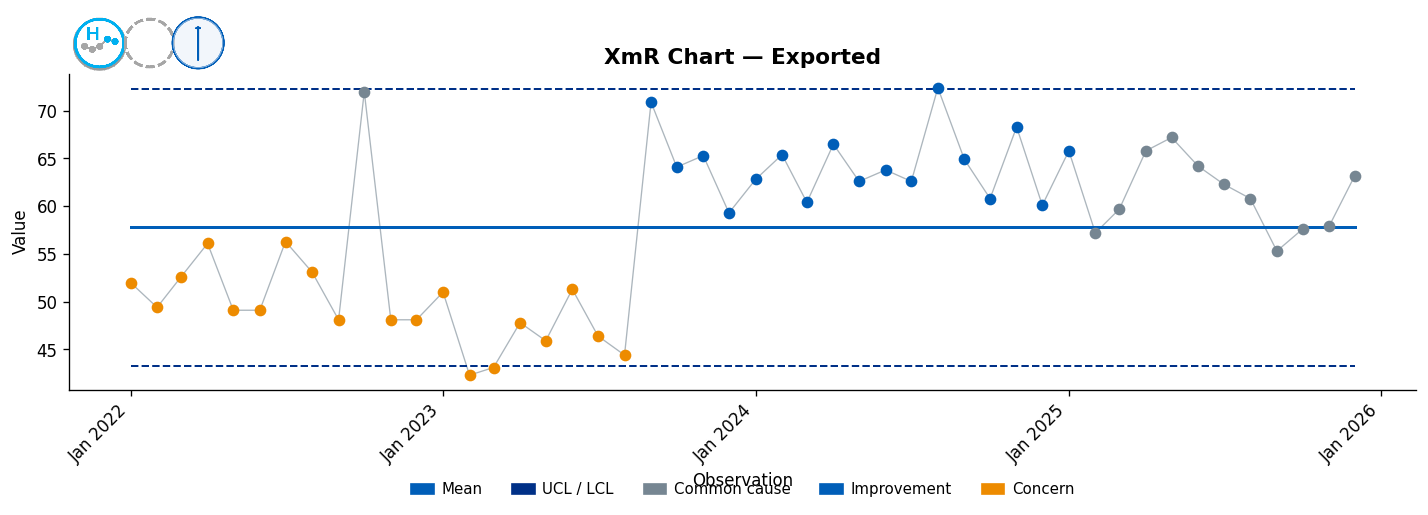

In [20]:
output_path = "spc_chart_output.png"

fig, ax = plot_spc_chart(
    df,
    chart_type="XmR",
    value_col=VALUE_COL,
    x_col=DATE_COL,
    title="XmR Chart — Exported",
    date_format="%b %Y",
    show_icons=True,
)
fig.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Chart saved to: {output_path}")
plt.show()

## 18. MDC Summary Table

Generate an NHS MDC-style summary table showing measure name, description,
variation icon, assurance icon, and the latest value — all in one view.

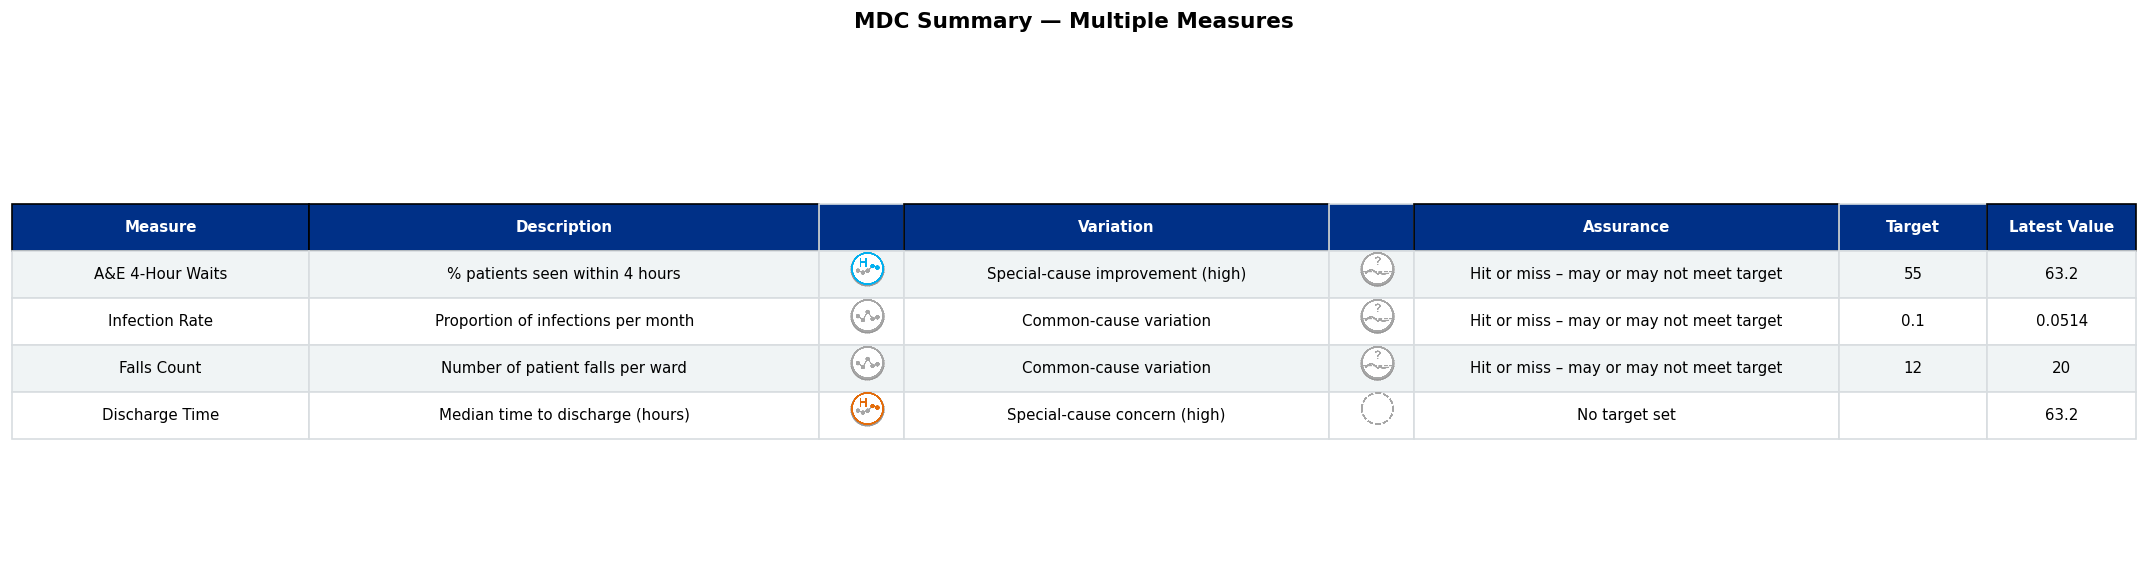

In [21]:
# Build a summary table with multiple measures
fig, ax = plot_mdc_summary_table(
    [
        {
            "data": df,
            "chart_type": "XmR",
            "measure": "A&E 4-Hour Waits",
            "description": "% patients seen within 4 hours",
            "value_col": VALUE_COL,
            "improvement_direction": "high",
            "target": 55,
        },
        {
            "data": df_p,
            "chart_type": "p",
            "measure": "Infection Rate",
            "description": "Proportion of infections per month",
            "value_col": "value",
            "improvement_direction": "low",
            "target": 0.10,
            "subgroup_col": "subgroup_size",
        },
        {
            "data": df_c,
            "chart_type": "c",
            "measure": "Falls Count",
            "description": "Number of patient falls per ward",
            "value_col": "value",
            "improvement_direction": "low",
            "target": 12,
        },
        {
            "data": df,
            "chart_type": "run",
            "measure": "Discharge Time",
            "description": "Median time to discharge (hours)",
            "value_col": VALUE_COL,
            "improvement_direction": "low",
        },
    ],
    title="MDC Summary — Multiple Measures",
)
plt.show()